In [1]:
import os
import sys

import warnings
warnings.filterwarnings('ignore')

project_root = 'c:/big20/git/big20-ML-project2-team3/SantanderCS'
# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'Malgun Gothic'
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score, recall_score
from utils.preprocessing import load_data, split_features_target, scale_data, data_split, remove_zero_columns2
from utils.user_utils import get_model_train_eval

In [3]:
# 데이터 로딩 및 기본 전처리
train, test = load_data()
X_features, y_labels = split_features_target(train)
X_test = test.drop(columns=['ID'], axis=1)

In [4]:

# zero_count_rate 제거
X_features, X_test = remove_zero_columns2(X_features, X_test, 0.95)

# var3 처리
X_features['var3'] =  X_features['var3'].replace(-999999, 2)


Train Data Analysis (Threshold: 95.0% )
Train rows: 76,020, columns: 369
Test rows: 75,818, columns: 369

                                   Train Summary (zero_count 내림차순)                                    
                   ColumnName  na_Sum  nUnique          mode  modeFreq modeFreqRate  zero_count zero_count_rate_display
saldo_medio_var13_medio_hace3       0        1      0.000000     76020      100.00%       76020                 100.00%
                     ind_var2       0        1      0.000000     76020      100.00%       76020                 100.00%
        num_reemb_var33_hace3       0        1      0.000000     76020      100.00%       76020                 100.00%
    num_trasp_var17_out_hace3       0        1      0.000000     76020      100.00%       76020                 100.00%
    num_trasp_var33_out_hace3       0        1      0.000000     76020      100.00%       76020                 100.00%
              saldo_var2_ult1       0        1      0.000000     76020

In [5]:

# threshold 리스트
thresholds = [0.85, 0.90, 0.95]

print(f"zero_count_rate > 0.95 이상 제거 후 : \n")
results = []
drop_columns = {}    # threshold별 삭제 컬럼 기록용

# 1. 상관계수 행렬 계산
corr_matrix = X_features.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# np.triu: 행렬 위쪽 삼각형만 남김, np.ones: 1로 가득 찬 행렬 생성

for th in thresholds:
    
    # 2. threshold 이상인 컬럼 drop
    to_drop = [column for column in upper.columns if any(upper[column] > th)]
    drop_columns[th] = to_drop
    X_reduced = X_features.drop(columns=to_drop)
    X_test_reduced = X_test.drop(columns=to_drop)
    
    # 3. 스케일링
    X_train_scaled, X_test_scaled, scaler = scale_data(X_reduced, X_test_reduced)
    
    # 4. 학습/검증 데이터 분리
    X_train, X_val, y_train, y_val = data_split(X_reduced, y_labels)
    
    model_name = 'LightGBM_95per_Corr_weight12'
    # 모델 학습
    lgbm_clf = LGBMClassifier(
        random_state      = 0,
        n_estimators      = 300,
        num_leaves        = 32,        # 가지 수
        min_child_samples = 24,
        class_weight = {0:1, 1:2},
        verbose           = -1
    )
    
    get_model_train_eval(lgbm_clf, model_name, X_train, X_val, y_train, y_val)
    
    # 6. 성능 평가
    y_pred = lgbm_clf.predict(X_val)
    y_proba = lgbm_clf.predict_proba(X_val)[:,1]
    
    auc = roc_auc_score(y_val, y_proba)
    f1 = f1_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    
    results.append({
        'threshold': th,
        'dropped_features' : len(to_drop),
        'AUC': auc,
        'F1' : f1,
        'Recall' : recall
    })
# 결과 출력
results_df = pd.DataFrame(results)
print(results_df)

zero_count_rate > 0.95 이상 제거 후 : 

✓ 모델 저장 완료: ../models\LightGBM_95per_Corr_weight12.pkl
  파일 크기: 1.01 MB
folder = c:\big20\git\big20-ML-project2-team3\SantanderCS\results
AUC: 0.8339, 정확도: 0.9590, 정밀도: 0.3158, 재현율: 0.0299, F1: 0.0546
오차행렬:
[[14563    39]
 [  584    18]]
실행 시간: 2.172173023223877
✓ 모델 저장 완료: ../models\LightGBM_95per_Corr_weight12.pkl
  파일 크기: 1.01 MB
folder = c:\big20\git\big20-ML-project2-team3\SantanderCS\results
AUC: 0.8336, 정확도: 0.9597, 정밀도: 0.3830, 재현율: 0.0299, F1: 0.0555
오차행렬:
[[14573    29]
 [  584    18]]
실행 시간: 0.8951489925384521
✓ 모델 저장 완료: ../models\LightGBM_95per_Corr_weight12.pkl
  파일 크기: 1.01 MB
folder = c:\big20\git\big20-ML-project2-team3\SantanderCS\results
AUC: 0.8329, 정확도: 0.9583, 정밀도: 0.2419, 재현율: 0.0249, F1: 0.0452
오차행렬:
[[14555    47]
 [  587    15]]
실행 시간: 0.972001314163208
   threshold  dropped_features       AUC        F1    Recall
0       0.85                43  0.833897  0.054628  0.029900
1       0.90                35  0.833554  0.055470  0

In [6]:

# threshold 리스트
thresholds = [0.85, 0.90, 0.95]

print(f"zero_count_rate > 0.95 이상 제거 후 : \n")
results = []
drop_columns = {}    # threshold별 삭제 컬럼 기록용

# 1. 상관계수 행렬 계산
corr_matrix = X_features.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# np.triu: 행렬 위쪽 삼각형만 남김, np.ones: 1로 가득 찬 행렬 생성

for th in thresholds:
    
    # 2. threshold 이상인 컬럼 drop
    to_drop = [column for column in upper.columns if any(upper[column] > th)]
    drop_columns[th] = to_drop
    X_reduced = X_features.drop(columns=to_drop)
    X_test_reduced = X_test.drop(columns=to_drop)
    
    # 3. 스케일링
    X_train_scaled, X_test_scaled, scaler = scale_data(X_reduced, X_test_reduced)
    
    # 4. 학습/검증 데이터 분리
    X_train, X_val, y_train, y_val = data_split(X_reduced, y_labels)
    
    model_name = 'LightGBM_95per_Corr_weight15'
    # 모델 학습
    lgbm_clf = LGBMClassifier(
        random_state      = 0,  # 랜덤 시드 고정 → 동일 데이터면 같은 결과 재현
        n_estimators      = 500, # 부스팅 반복 횟수(트리 개수), 많으면 학습 충분, 적으면 부족
        num_leaves        = 32, # 하나 트리의 최대 잎사귀 수 → 트리 복잡도 조절          
        min_child_samples = 18, # 리프 하나가 가져야 할 최소 샘플 수 → 과적합 방지, 양성 샘플 확보            
        class_weight      = {0:1, 1:5}, # 불균형 데이터에서 양성 클래스(1)에 가중치 부여 → 재현율 향상
        learning_rate     = 0.05, # 학습률 → 낮으면 안정적, 많으면 빠르지만 과적합 가능
        subsample         = 0.8, # 행(row) 샘플링 비율 → 과적합 방지, 트리 다양성 증가
        colsample_bytree  = 0.8, # 열(feature) 샘플링 비율 → 과적합 방지, 트리 다양성 증가
        verbose           = -1 
    )
    
    get_model_train_eval(lgbm_clf, model_name, X_train, X_val, y_train, y_val)
    
    # 6. 성능 평가
    y_pred = lgbm_clf.predict(X_val)
    y_proba = lgbm_clf.predict_proba(X_val)[:,1]
    
    auc = roc_auc_score(y_val, y_proba)
    f1 = f1_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    
    results.append({
        'threshold': th,
        'dropped_features' : len(to_drop),
        'AUC': auc,
        'F1' : f1,
        'Recall' : recall
    })
# 결과 출력
results_df = pd.DataFrame(results)
print(results_df)

zero_count_rate > 0.95 이상 제거 후 : 

✓ 모델 저장 완료: ../models\LightGBM_95per_Corr_weight15.pkl
  파일 크기: 1.69 MB
folder = c:\big20\git\big20-ML-project2-team3\SantanderCS\results
AUC: 0.8339, 정확도: 0.9290, 정밀도: 0.2405, 재현율: 0.3671, F1: 0.2906
오차행렬:
[[13904   698]
 [  381   221]]
실행 시간: 1.3999500274658203
✓ 모델 저장 완료: ../models\LightGBM_95per_Corr_weight15.pkl
  파일 크기: 1.69 MB
folder = c:\big20\git\big20-ML-project2-team3\SantanderCS\results
AUC: 0.8360, 정확도: 0.9280, 정밀도: 0.2309, 재현율: 0.3505, F1: 0.2784
오차행렬:
[[13899   703]
 [  391   211]]
실행 시간: 1.479529857635498
✓ 모델 저장 완료: ../models\LightGBM_95per_Corr_weight15.pkl
  파일 크기: 1.70 MB
folder = c:\big20\git\big20-ML-project2-team3\SantanderCS\results
AUC: 0.8347, 정확도: 0.9267, 정밀도: 0.2291, 재현율: 0.3605, F1: 0.2802
오차행렬:
[[13872   730]
 [  385   217]]
실행 시간: 1.6200015544891357
   threshold  dropped_features       AUC        F1    Recall
0       0.85                43  0.833941  0.290598  0.367110
1       0.90                35  0.836025  0.278364  

In [7]:
# threshold별 삭제된 컬럼 집합 (drop_columns dict에서 가져오기)
set_085 = set(drop_columns[0.85])
set_090 = set(drop_columns[0.90])
set_095 = set(drop_columns[0.95])

# 고유하게 삭제된 컬럼
unique_085 = set_085 - set_090 - set_095
unique_090 = set_090 - set_085 - set_095
unique_095 = set_095 - set_085 - set_090

print("0.85에서만 삭제된:", unique_085)
print("0.90에서만 삭제된:", unique_090)
print("0.95에서만 삭제된:", unique_095)

# 공통 삭제된 컬럼
common_all = set_085 & set_090 & set_095
print("모든 threshold에서 공통 삭제된:", common_all)

# unique/공통 컬럼 비교용 DataFrame
tmpdf = pd.DataFrame(dict([(k, pd.Series(v)) for k,v in drop_columns.items()]))
tmpdf.to_csv("../data/99per_drop_columns.xls", index=False)


0.85에서만 삭제된: {'num_var30', 'num_var42', 'imp_op_var41_ult1', 'ind_var10_ult1', 'imp_op_var39_comer_ult3', 'num_var12_0', 'num_var45_ult1', 'num_var39_0'}
0.90에서만 삭제된: set()
0.95에서만 삭제된: set()
모든 threshold에서 공통 삭제된: {'ind_var41_0', 'imp_op_var39_ult1', 'num_var35', 'num_op_var39_ult3', 'num_op_var39_ult1', 'num_op_var41_comer_ult3', 'num_var5', 'num_var13', 'num_var37', 'num_op_var39_efect_ult1', 'ind_var9_ult1', 'imp_op_var41_comer_ult1', 'imp_op_var39_efect_ult3', 'num_op_var39_hace2', 'num_var45_ult3', 'imp_op_var41_comer_ult3', 'num_op_var39_efect_ult3', 'ind_var37', 'num_var13_0', 'ind_var9_cte_ult1', 'ind_var13', 'num_op_var41_comer_ult1', 'num_var41_0', 'imp_op_var39_efect_ult1'}


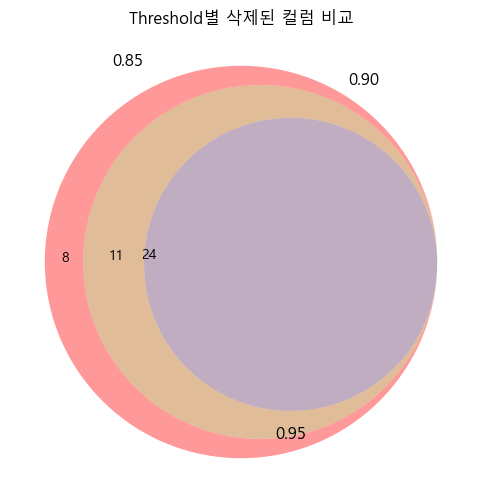

In [8]:
# Venn Diagram 그리기
# pip install matplotlib_venn
from matplotlib_venn import venn3

plt.figure(figsize=(8,6))
venn3([set_085, set_090, set_095], set_labels=('0.85','0.90','0.95'))
plt.title('Threshold별 삭제된 컬럼 비교')
plt.show()

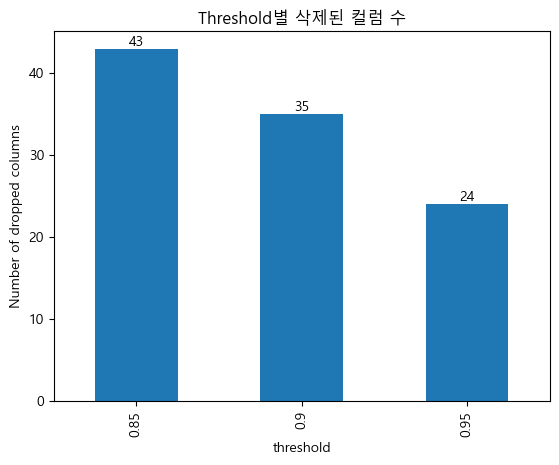

In [9]:
import matplotlib.pyplot as plt

ax = results_df.plot(
    x="threshold", 
    y="dropped_features", 
    kind="bar", 
    legend=False
)

plt.title("Threshold별 삭제된 컬럼 수")
plt.ylabel("Number of dropped columns")

# 막대 위에 수치 레이블 추가
ax.bar_label(ax.containers[0])

plt.show()


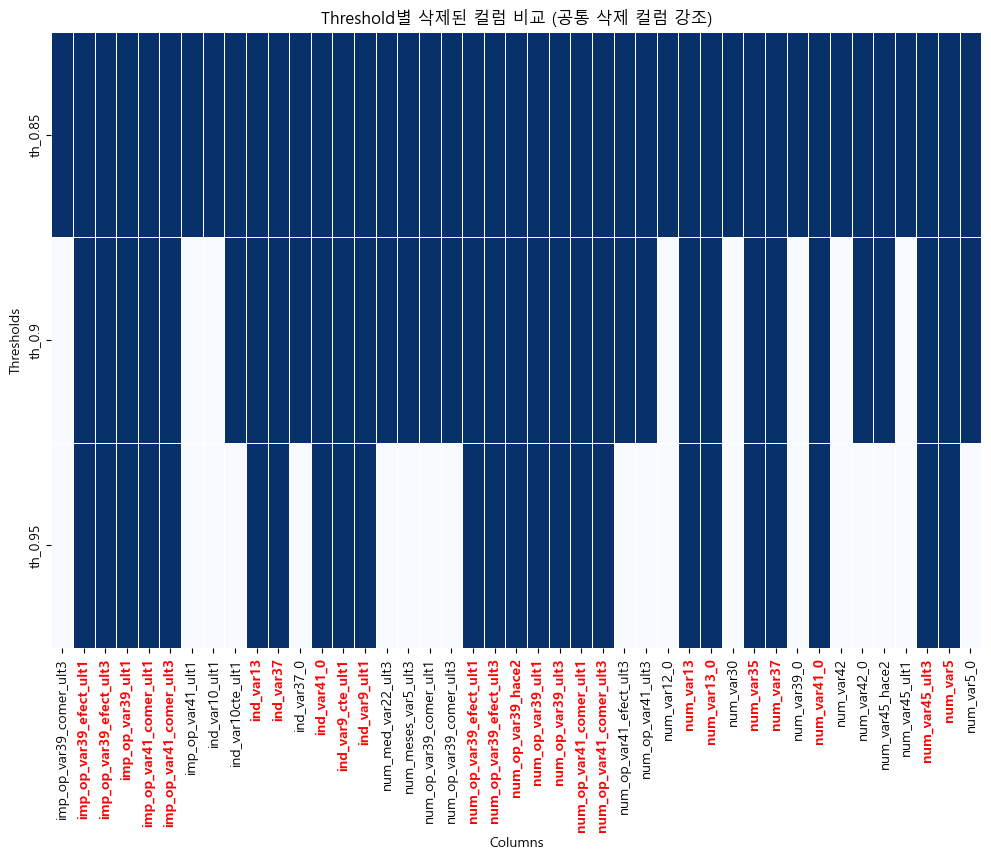

In [10]:
# 존재 여부 매트릭스 생성 (앞에서 만든 comparison_matrix)
# drop_columns 딕셔너리 안에 있는 모든 컬럼을 합쳐서 집합 생성
all_dropped = set()
for cols in drop_columns.values():
    all_dropped.update(cols)
    
comparison_matrix = pd.DataFrame(index=sorted(all_dropped))
for th, cols in drop_columns.items():
    comparison_matrix[f"th_{th}"] = comparison_matrix.index.isin(cols)
comparison_matrix = comparison_matrix.astype(int)

# 공통으로 삭제된 컬럼
common_all = set(drop_columns[0.85]) & set(drop_columns[0.90]) & set(drop_columns[0.95])

# heatmap 그리기
plt.figure(figsize=(12,8))
ax = sns.heatmap(comparison_matrix.T, cmap="Blues", cbar=False, linewidths=0.5)

# 공통 삭제된 컬럼에 대해 x축 라벨 색상 변경
for label in ax.get_xticklabels():
    if label.get_text() in common_all:
        label.set_color("red")   # 공통 삭제된 컬럼은 빨간색
        label.set_fontweight("bold")

plt.title("Threshold별 삭제된 컬럼 비교 (공통 삭제 컬럼 강조)")
plt.xlabel("Columns")
plt.ylabel("Thresholds")
plt.show()